Loading data from: /final.xlsx
Total valid rows for training: 560
Training Random Forest Regressor...

--- Model Results ---
R-squared (Accuracy): 0.8640
RMSE (Average Error): 255.38 kN


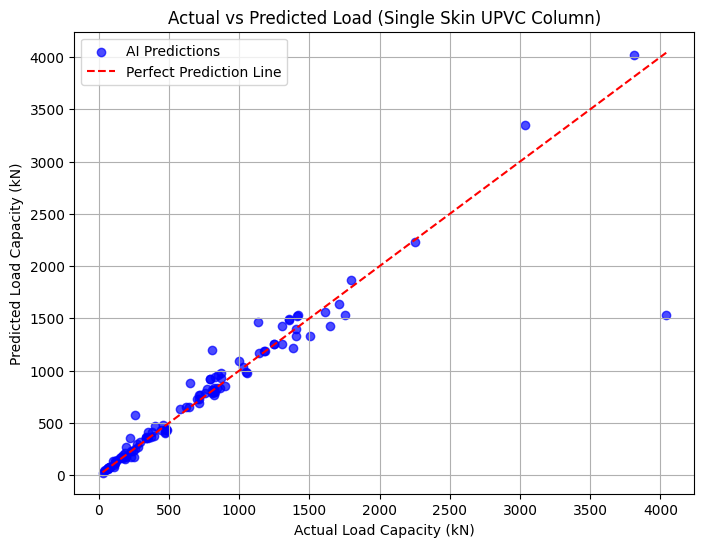

In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Find the file correctly
file_path = 'final.xlsx'
if os.path.exists('/final.xlsx'):
    file_path = '/final.xlsx'
elif os.path.exists('/content/final.xlsx'):
    file_path = '/content/final.xlsx'

print(f"Loading data from: {file_path}")

# 2. Load the Data (header=2 means 3rd row in Excel, where your titles actually are)
df = pd.read_excel(file_path, sheet_name='Single_Skin_Pipe', header=2)
df = df.dropna(axis=1, how='all') # Drop completely empty columns

# 3. Clean the 'OUTPUT' column (Convert to numeric and remove empty rows)
df['OUTPUT: Pu,max,avg. (kN)'] = pd.to_numeric(df['OUTPUT: Pu,max,avg. (kN)'], errors='coerce')
df = df.dropna(subset=['OUTPUT: Pu,max,avg. (kN)'])
print(f"Total valid rows for training: {len(df)}")

# 4. Define Features (X) and Target (y)
y = df['OUTPUT: Pu,max,avg. (kN)']
X = df.drop(columns=['Specimen', 'OUTPUT: Pu,max,avg. (kN)'], errors='ignore')

# Clean up unwanted extra columns (like 'Unnamed: 13' that have no data)
cols_to_drop = [c for c in X.columns if 'Unnamed' in str(c) or isinstance(c, int)]
X = X.drop(columns=cols_to_drop, errors='ignore')

# Convert all inputs to numbers and fill missing spaces with 0
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train the Model
print("Training Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. Evaluate the Model
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("\n--- Model Results ---")
print(f"R-squared (Accuracy): {r2:.4f}")
print(f"RMSE (Average Error): {rmse:.2f} kN")

# 8. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='blue', label='AI Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel('Actual Load Capacity (kN)')
plt.ylabel('Predicted Load Capacity (kN)')
plt.title('Actual vs Predicted Load (Single Skin UPVC Column)')
plt.legend()
plt.grid(True)
plt.show()

Please select 'final.xlsx' from your computer:


Saving final.xlsx to final.xlsx

Training all models, please wait a few seconds...

Random Forest Accuracy: 86.40%
Gradient Boosting Accuracy: 85.37%
Support Vector Machine Accuracy: 81.04%


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Artificial Neural Network Accuracy: 79.25%


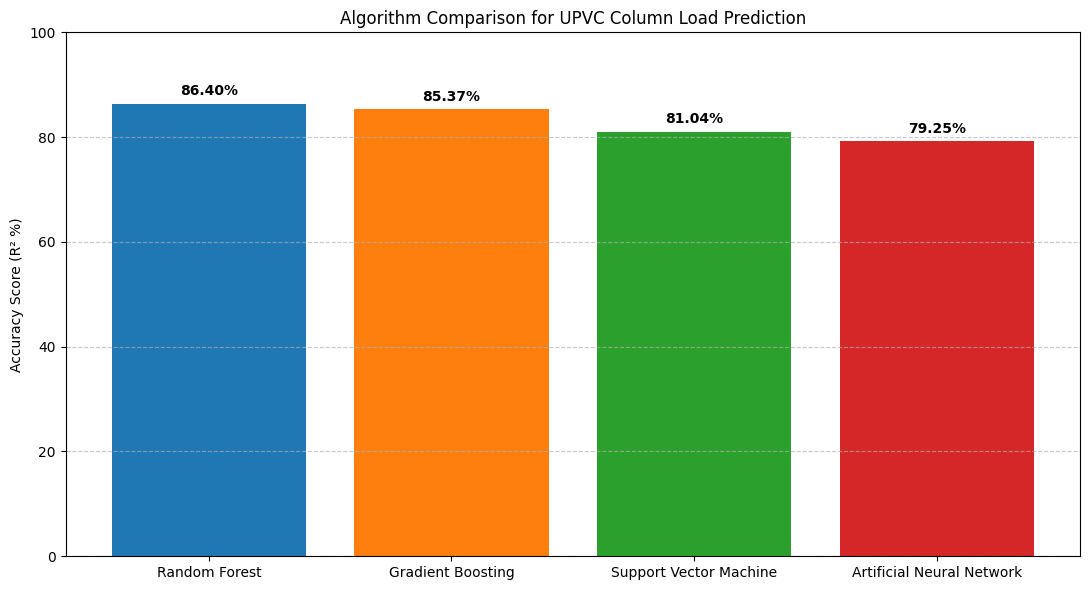

In [10]:
import os
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# 1. Direct File Upload from Code (Ekhane 'Choose Files' button asbe)
print("Please select 'final.xlsx' from your computer:")
uploaded = files.upload()

# File path will automatically be set to the uploaded file
file_path = list(uploaded.keys())[0]

# 2. Load Data
df = pd.read_excel(file_path, sheet_name='Single_Skin_Pipe', header=2)
df = df.dropna(axis=1, how='all')

# 3. Clean the 'OUTPUT' column
df['OUTPUT: Pu,max,avg. (kN)'] = pd.to_numeric(df['OUTPUT: Pu,max,avg. (kN)'], errors='coerce')
df = df.dropna(subset=['OUTPUT: Pu,max,avg. (kN)'])

# 4. Define Features (X) and Target (y)
y = df['OUTPUT: Pu,max,avg. (kN)']
X = df.drop(columns=['Specimen', 'OUTPUT: Pu,max,avg. (kN)'], errors='ignore')

# Clean columns and force them to numbers
cols_to_drop = [c for c in X.columns if 'Unnamed' in str(c) or isinstance(c, int)]
X = X.drop(columns=cols_to_drop, errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Data Scaling (CRUCIAL for SVM and ANN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Initialize All 4 Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Support Vector Machine": SVR(kernel='rbf', C=5000, gamma='scale'),
    "Artificial Neural Network": MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42)
}

# 8. Train and Record Accuracy
accuracy_results = {}

print("\nTraining all models, please wait a few seconds...\n")
for name, model in models.items():
    if name in ["Support Vector Machine", "Artificial Neural Network"]:
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    r2 = r2_score(y_test, predictions)
    accuracy_results[name] = r2 * 100
    print(f"{name} Accuracy: {r2 * 100:.2f}%")

# 9. Plot the Comparison Bar Chart
plt.figure(figsize=(11, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = plt.bar(accuracy_results.keys(), accuracy_results.values(), color=colors)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 100)
plt.ylabel('Accuracy Score (R² %)')
plt.title('Algorithm Comparison for UPVC Column Load Prediction')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Checking for data file...
File found automatically!
Finding out the most important features...


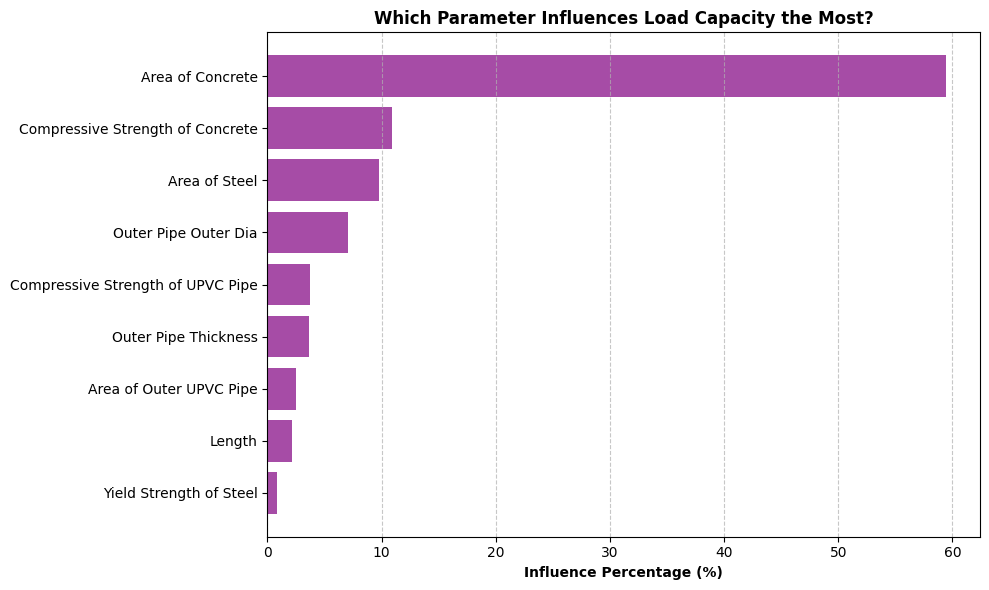

In [11]:
import os
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from google.colab import files

# Check if file exists, otherwise ask to upload
print("Checking for data file...")
if not os.path.exists('final.xlsx') and not os.path.exists('/content/final.xlsx'):
    print("File not found! Please upload 'final.xlsx':")
    uploaded = files.upload()
    file_path = list(uploaded.keys())[0]
else:
    file_path = '/content/final.xlsx' if os.path.exists('/content/final.xlsx') else 'final.xlsx'
    print("File found automatically!")

# Load Data & Clean
df = pd.read_excel(file_path, sheet_name='Single_Skin_Pipe', header=2)
df = df.dropna(axis=1, how='all')
df['OUTPUT: Pu,max,avg. (kN)'] = pd.to_numeric(df['OUTPUT: Pu,max,avg. (kN)'], errors='coerce')
df = df.dropna(subset=['OUTPUT: Pu,max,avg. (kN)'])
y = df['OUTPUT: Pu,max,avg. (kN)']
X = df.drop(columns=['Specimen', 'OUTPUT: Pu,max,avg. (kN)'], errors='ignore')

# Drop empty columns and make numeric
cols_to_drop = [c for c in X.columns if 'Unnamed' in str(c) or isinstance(c, int)]
X = X.drop(columns=cols_to_drop, errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Clean up column names to look nice on the graph
clean_cols = [c.split('(')[0].replace('INPUT:', '').replace('\n', '').strip() for c in X.columns]
X.columns = clean_cols

# Train the Best Model (Random Forest) on ALL data
print("Finding out the most important features...")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Extract Feature Importance
importances = model.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance Score': importances * 100})
feat_df = feat_df.sort_values(by='Importance Score', ascending=True)

# Plot the graph
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance Score'], color='purple', alpha=0.7)
plt.xlabel('Influence Percentage (%)', fontweight='bold')
plt.title('Which Parameter Influences Load Capacity the Most?', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
import os
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import gradio as gr

# 1. Data load ar Model Train kora
file_path = '/content/final.xlsx' if os.path.exists('/content/final.xlsx') else 'final.xlsx'
df = pd.read_excel(file_path, sheet_name='Single_Skin_Pipe', header=2)
df = df.dropna(axis=1, how='all')
df['OUTPUT: Pu,max,avg. (kN)'] = pd.to_numeric(df['OUTPUT: Pu,max,avg. (kN)'], errors='coerce')
df = df.dropna(subset=['OUTPUT: Pu,max,avg. (kN)'])
y = df['OUTPUT: Pu,max,avg. (kN)']
X = df.drop(columns=['Specimen', 'OUTPUT: Pu,max,avg. (kN)'], errors='ignore')

cols_to_drop = [c for c in X.columns if 'Unnamed' in str(c) or isinstance(c, int)]
X = X.drop(columns=cols_to_drop, errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

def predict_load(length, thickness, outer_dia, area_concrete, fck, area_steel, fy, fp, area_outer_upvc):
    input_data = pd.DataFrame([[length, thickness, outer_dia, area_concrete, fck, area_steel, fy, fp, area_outer_upvc]], columns=X.columns)
    prediction = model.predict(input_data)[0]
    return f"⚡ AI Predicted Maximum Load: {prediction:.2f} kN"

# 2. "Paglami" Level Portfolio CSS
custom_css = """
/* Clean Deep Dark Gradient Background */
body, gradio-app, #root {
    background: linear-gradient(135deg, #0f172a 0%, #1e1b4b 50%, #020617 100%) !important;
    background-attachment: fixed !important;
}

/* App er Main Box */
.gradio-container {
    background: rgba(30, 41, 59, 0.4) !important;
    backdrop-filter: blur(16px) !important;
    border-radius: 20px !important;
    box-shadow: 0 25px 50px -12px rgba(0, 0, 0, 0.5) !important;
    border: 1px solid rgba(255, 255, 255, 0.1) !important;
    max-width: 1200px !important;
    padding: 30px !important;
    color: white !important;
}

/* Transparent inner boxes */
.gradio-container .gr-box, .gradio-container .gr-panel {
    background: transparent !important;
    border: 1px solid rgba(255, 255, 255, 0.05) !important;
}

/* Run Button */
button.primary {
    background: linear-gradient(90deg, #10b981, #3b82f6) !important; /* Green to Blue for Eco-Tech */
    border: none !important;
    box-shadow: 0 4px 15px rgba(59, 130, 246, 0.5) !important;
    color: white !important;
    font-weight: bold !important;
    transition: transform 0.2s;
}
button.primary:hover {
    transform: scale(1.02);
}

/* Argho's Custom Profile Card */
.profile-card {
    background: rgba(255, 255, 255, 0.03);
    border-radius: 15px;
    padding: 25px;
    border-left: 5px solid #10b981;
    margin-top: 10px;
    box-shadow: inset 0 0 20px rgba(0,0,0,0.2);
}
.highlight-badge {
    background: rgba(16, 185, 129, 0.15);
    color: #34d399;
    padding: 6px 12px;
    border-radius: 20px;
    font-size: 0.9em;
    font-weight: 600;
    margin-right: 10px;
    display: inline-block;
    margin-bottom: 8px;
    border: 1px solid rgba(52, 211, 153, 0.3);
}
"""

with gr.Blocks(css=custom_css) as app:

    # 🌟 App Header
    gr.HTML(
        """
        <div style="text-align: center; padding: 10px; margin-bottom: 5px;">
            <h1 style="font-size: 4em; font-weight: 900; background: -webkit-linear-gradient(#34d399, #3b82f6); -webkit-background-clip: text; -webkit-text-fill-color: transparent; margin-bottom: 0px; text-shadow: 2px 2px 10px rgba(0,0,0,0.5);">
                🏗️ CivCode AI v2.0
            </h1>
            <h3 style="color: #9ca3af; font-weight: 400; margin-top: 5px; letter-spacing: 2px;">SUSTAINABLE STRUCTURES ENGINEERING TOOL</h3>
        </div>
        """
    )

    # 🔥 The "Crazy" Portfolio Section integration
    gr.HTML(
        """
        <div class="profile-card">
            <h2 style="margin-top: 0; color: white;">Architected by <b style="background: -webkit-linear-gradient(#a5f3fc, #3b82f6); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Argho Dutta</b></h2>
            <p style="color: #cbd5e1; font-size: 1.1em; margin-bottom: 15px;">
                🎓 B.Tech Civil Engineering @ HIT | 🌍 Future Sustainable Structural Engineer
            </p>
            <div>
                <span class="highlight-badge">🔬 Researcher: Alkali-Activated Concrete</span>
                <span class="highlight-badge">🏭 HPL & PWD Experienced</span>
                <span class="highlight-badge">📝 Published Author (The Penlighten)</span>
                <span class="highlight-badge">🏆 Debate Winner</span>
                <span class="highlight-badge">🤖 Machine Learning for Civil Eng.</span>
            </div>
            <p style="color: #94a3b8; font-size: 0.9em; margin-top: 15px; font-style: italic;">
                "Bridging the gap between eco-friendly construction materials and data-driven predictive modeling."
            </p>
        </div>
        <hr style="border-color: rgba(255,255,255,0.1); margin-top: 25px; margin-bottom: 25px;"/>
        """
    )

    # 3-Column Neat Layout
    with gr.Row():
        with gr.Column(scale=1, min_width=300):
            gr.Markdown("### 📏 Dimensions")
            length = gr.Number(label="Length (mm)", value=500)
            thickness = gr.Number(label="Outer Pipe Thickness (mm)", value=4.25)
            outer_dia = gr.Number(label="Outer Dia (mm)", value=160)

        with gr.Column(scale=1, min_width=300):
            gr.Markdown("### 🏗️ Material Properties")
            area_concrete = gr.Number(label="Area of Concrete (mm²)", value=18026)
            fck = gr.Number(label="Concrete Strength - fck (MPa)", value=23.6)
            area_outer_upvc = gr.Number(label="Area of Outer UPVC Pipe (mm²)", value=2079)

        with gr.Column(scale=1, min_width=300):
            gr.Markdown("### ⚙️ Steel Properties")
            area_steel = gr.Number(label="Area of Steel", value=0)
            fy = gr.Number(label="Yield Strength of Steel - fy", value=0)
            fp = gr.Number(label="Compressive Strength of UPVC - fp", value=0)

    # Output Section
    with gr.Row():
        predict_btn = gr.Button("🚀 Run AI Structural Simulation", variant="primary", size="lg")

    with gr.Row():
        output_box = gr.Textbox(label="AI Prediction Result", lines=2)

    predict_btn.click(
        fn=predict_load,
        inputs=[length, thickness, outer_dia, area_concrete, fck, area_steel, fy, fp, area_outer_upvc],
        outputs=output_box
    )

# 3. App Launch
app.launch(share=True)

/tmp/ipykernel_2349/3763691316.py:89: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(css=custom_css) as app:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b54ca3c881a3a8bff1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
